* https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.expanding.html
* https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.rolling.html

In [9]:
import pandas as pd
import numpy as np
%matplotlib inline

In [ ]:
# 2023년 1월 1일부터 1,000일 동안 랜덤한 데이터 생성
s = pd.Series(np.random.randn(1000),
              index=pd.date_range('1/1/2023', periods=1000))

<Axes: >

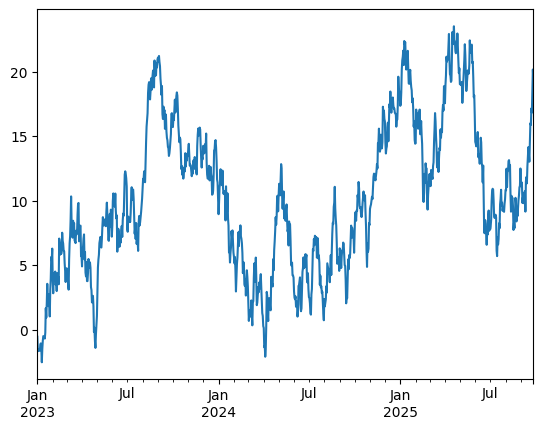

In [ ]:
# 이전 값들에 현재 변동량을 누적 합산
s = s.cumsum()

# 데이터를 선 그래프(Line Plot)로 시각화
s.plot()

In [ ]:
# 데이터를 60개씩 묶어서 rolling(굴린다?)
# window=60: 현재 시점을 기준으로 지난 60일의 데이터(데이터 60개)를 한 묶음으로 취급
r = s.rolling(window=60)
r.mean()

2023-01-01          NaN
2023-01-02          NaN
2023-01-03          NaN
2023-01-04          NaN
2023-01-05          NaN
                ...    
2025-09-22    11.034600
2025-09-23    11.151029
2025-09-24    11.306131
2025-09-25    11.484600
2025-09-26    11.651601
Freq: D, Length: 1000, dtype: float64

<Axes: >

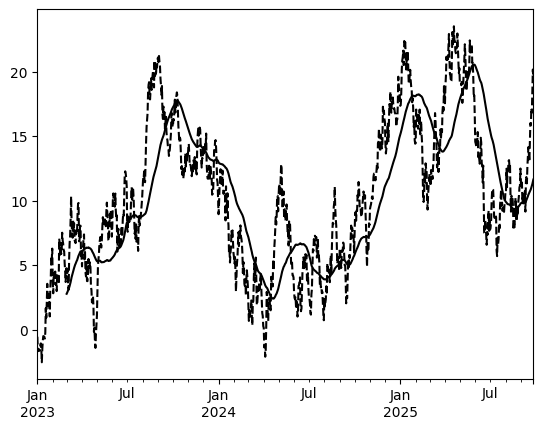

In [ ]:
# 이동평균을 구할 때 추세선 사용

# style='k--': k는 검정색을 의미, --는 선의 모양(Line Style) 파선을 의미
# 검정색 점선 스타일로 그래프 시각화
s.plot(style='k--')

# 60일간의 이동평균을 구해(r) 매끄러운 추세선으로 시각화
r.mean().plot(style='k')

In [26]:
df = pd.DataFrame(np.random.randn(1000, 4),
                  index=pd.date_range('1/1/2023', periods=1000),
                  columns=['A', 'B', 'C', 'D'])

In [27]:
df

,A,B,C,D
2023-01-01,0.497852,1.408603,0.293391,0.526319
2023-01-02,0.817090,-0.304637,1.085032,0.506727
2023-01-03,0.585139,0.157496,0.038769,-1.434306
2023-01-04,-1.288447,0.565454,-0.187242,1.411942
2023-01-05,0.542766,0.901363,0.145988,-0.622403
...,...,...,...,...
2025-09-22,-1.094815,-0.537362,-0.859244,1.378785
2025-09-23,-1.859796,-0.508956,0.903356,0.246250
2025-09-24,-0.848359,-1.403028,1.102277,0.175734
2025-09-25,0.020272,0.204547,0.603267,0.171129


<Axes: >

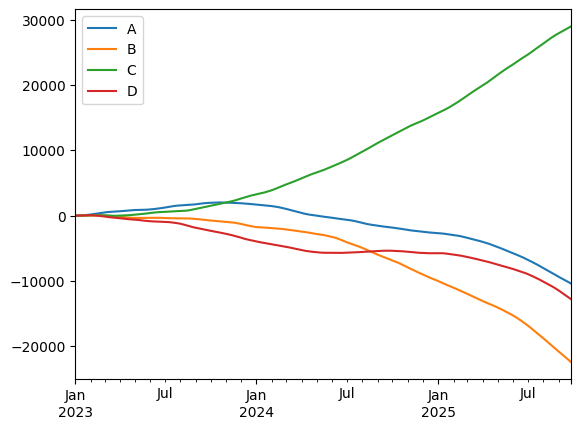

In [29]:
df = df.cumsum()
df.plot()

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

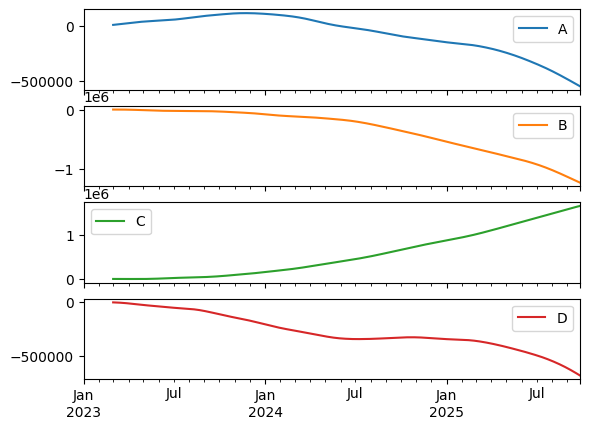

In [30]:
# subplots=True: 네 개의 컬럼(A, B, C, D)를 4개의 독립된 그래프로 만들어 출력
df.rolling(window=60).sum().plot(subplots=True)

<Axes: >

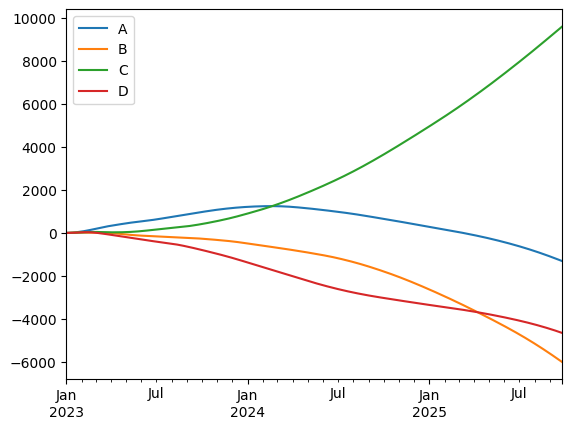

In [32]:
# window=len(df): 데이터의 전체 개수(1000개),
#                 데이터가 쌓일수록 창문 크기가 커지는 '누적 확장 평균' 계산
# min_periods=1: 데이터가 최소 1개만 있어도 평균을 내준다
df.rolling(window=len(df), min_periods=1).mean().plot()

<Axes: >

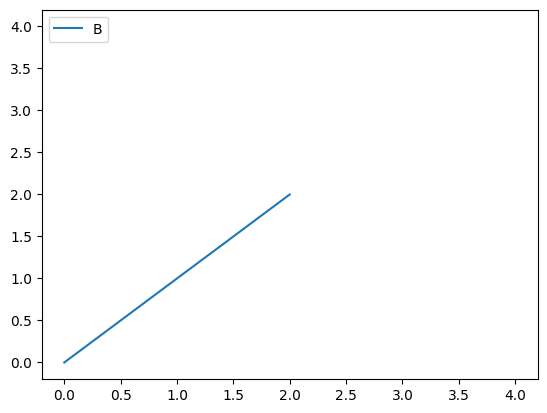

In [ ]:
dfe = pd.DataFrame({'B': [0, 1, 2, np.nan, 4]}) 

# NaN 구간에서 선이 끊긴 그래프
dfe.plot()

<Axes: >

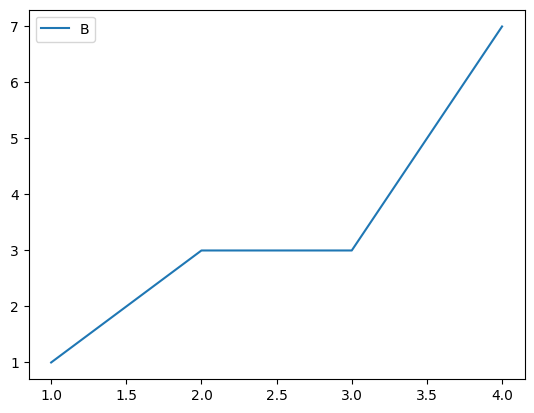

In [ ]:
# expanding(2): 최소 2개의 데이터가 모일 때부터 계산 시작
# NaN 구간에는 그래프 변동 X
dfe.expanding(2).sum().plot()